In [4]:
import numpy as np
import h5py

In [27]:
def f(x):
    return np.sin(x)

def df(x):
    return np.cos(x)

x0= 1
dx = np.logspace(-1, -5, 20)

df_forward=(f(x0+dx)-f(x0))/dx
df_center=(f(x0+dx)-f(x0-dx))/(2*dx)

df_exact=df(x0)

err_forward=np.abs(df_forward-df_exact)
err_center=np.abs(df_center-df_exact)

with h5py.File("finite_diff.h5", "w") as file:

    file.create_dataset("dx", data=dx)

    file.create_dataset(
        "forward/derivative",
        data=df_forward
    )

    file.create_dataset(
        "forward/error",
        data=err_forward
    )

    file.create_dataset(
        "centered/derivative",
        data=df_center
    )

    file.create_dataset(
        "centered/error",
        data=err_center
    )

    file.attrs["x0"] = x0
    file.attrs["df_exact"] = df_exact

In [28]:
import h5py
import matplotlib.pyplot as plt

with h5py.File("finite_diff.h5", "r") as file:

    dx = file["dx"][:]

    error_forward = file["forward/error"][:]
    error_centered = file["centered/error"][:]

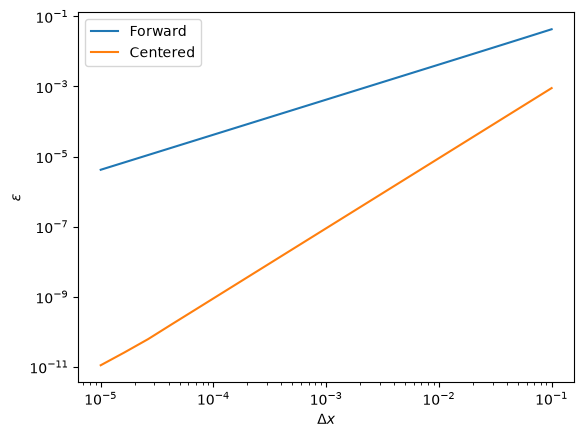

In [35]:
plt.loglog(dx, error_forward, label="Forward")
plt.loglog(dx, error_centered, label="Centered")
plt.xlabel(r"$\Delta x$")
plt.ylabel(r"$\epsilon$")
plt.legend()
